In [21]:
pip install IPython

Note: you may need to restart the kernel to use updated packages.


In [23]:
from langgraph.graph import StateGraph, START, END
from IPython.display import Image
from typing import TypedDict

In [25]:
#define state
class BMIState(TypedDict):
    weight: float
    height: float
    bmi: float
    category: str

In [28]:
graph = StateGraph(BMIState)

In [29]:
#define Node
def calculator(state : BMIState) -> BMIState:
    weight = state['weight']
    height = state['height']
    bmi = weight / (height ** 2)
    state["bmi"] = round(bmi, 2)
    return state

In [30]:
def categorize(state : BMIState) -> BMIState:
    bmi = state['bmi']
    if bmi < 18.5:
        state["category"] = "Underweight"
    elif 18.5 <= bmi < 25:
        state["category"] = "Normal"
    elif 25 <= bmi < 30:
        state["category"] = "Overweight"
    else:
        state["category"] = "Obese"

    return state

In [31]:
graph.add_node( "BMI Calculator", calculator)
graph.add_node( "BMI Categorizer", categorize)

In [32]:
graph.add_edge(START, "BMI Calculator")
graph.add_edge("BMI Calculator", "BMI Categorizer")
graph.add_edge("BMI Categorizer", END)

In [33]:
app = graph.compile()

In [34]:
result = app.invoke({"weight": 70, "height": 1.75})

In [35]:
print(result)

{'weight': 70, 'height': 1.75, 'bmi': 22.86, 'category': 'Normal'}


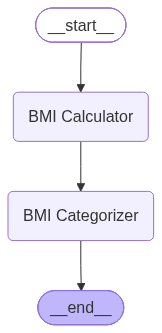

In [36]:
Image(app.get_graph().draw_mermaid_png())